# EDA - Análisis exploratorio de datos: RRHH

**Repaso de todo lo aprendido en el curso**: Lectura de ficheros, pandas (exploración y limpieza) y numpy (operaciones matemáticas), y visualizacion con matplotlib, seaborn y 

## StoryTelling: Contexto

Formáis parte del equipo de análisis de datos del departamento de **Recursos Humanos** de una empresa.

Nos han exportado un extracto de la base de datos de personal (`data/empleados_rrhh.csv`) y dirección os pide un **informe exploratorio** para entender cómo está compuesta la plantilla antes de tomar decisiones (revisión salarial, plan de teletrabajo, etc.).

Como en cualquier dataset real, **los datos no llegan limpios**: habrá nulos, departamentos escritos de formas distintas y filas duplicadas. Vamos a seguir el proceso típico de un EDA:

1. Carga de datos
2. Primera exploración
3. Calidad de datos (nulos, duplicados, inconsistencias)
4. Limpieza
5. Análisis univariante (una variable) + visualización
6. Análisis bivariante (relación entre variables) + visualización
7. Correlación entre variables numéricas
8. Un gráfico interactivo con Plotly
9. Conclusiones

## 0. Importación de librerias y configuracion iniciales.

- revisar que nuestro entorno de desarrollo esta activado y que tenemos todas las librerias instaladas.

In [377]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import requests as rq

sns.set_theme(style="whitegrid")


## 1. Carga de datos
Empezemos siempre igual, los datos o bien viene de base de datos, API, o de un fichero.

In [378]:
df = pd.read_csv('./data/empleados_rrhh.csv')
df.head()

,id_empleado,nombre,departamento,genero,edad,antiguedad_anios,salario_anual,satisfaccion,horas_extra_mes,teletrabajo
0,79,Beatriz Rubio,Marketing,Hombre,42.0,11.0,32852.78,6.0,18,False
1,151,Ana López,marketing,Hombre,47.0,11.0,36555.44,9.0,1,True
2,172,Teresa Ruiz,ventas,Mujer,52.0,14.0,38518.68,6.0,17,True
3,65,Pablo Blanco,RRHH,Mujer,35.0,8.0,27203.22,6.0,7,False
4,191,Silvia Gómez,VENTAS,Mujer,50.0,14.0,37651.75,5.0,17,True


## 2. Primera exploración
Antes de tocar nada, necesitamos entender qué tenemos entre manos:
    - Cuántas filas
    - Cuántas columnas
    - tipos datos
    - Donde están los valores numéricos

In [379]:
print('Dimensiones (filas, columnas)', df.shape )
df.info()

Dimensiones (filas, columnas) (230, 10)
<class 'pandas.DataFrame'>
RangeIndex: 230 entries, 0 to 229
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_empleado       230 non-null    int64  
 1   nombre            230 non-null    str    
 2   departamento      230 non-null    str    
 3   genero            230 non-null    str    
 4   edad              219 non-null    float64
 5   antiguedad_anios  222 non-null    float64
 6   salario_anual     217 non-null    float64
 7   satisfaccion      224 non-null    float64
 8   horas_extra_mes   230 non-null    int64  
 9   teletrabajo       230 non-null    bool   
dtypes: bool(1), float64(4), int64(2), str(3)
memory usage: 16.5 KB


Fijaos en dos cosas df.info()
    - Hay columnas con menos valores no nulos que filas totales -> Tenemos valores nulos
    - Comprobar que no hay id_empleado duplicado

### Resumen estadistico: Todas estadisticas tipica, media, mediana, mix, max, cuartiles, etc.

In [380]:
#df.describe()
df['edad'].describe()

count    219.000000
mean      42.132420
std       11.568139
min       22.000000
25%       32.000000
50%       42.000000
75%       52.000000
max       60.000000
Name: edad, dtype: float64

## 3 Calidad de los datos
Antes limpiar, hay que **detectar** los problemas. Vamos a revisar la cantidad de nulos, duplicados.

In [381]:
# 3.1 Nulos por columna
df.isnull().sum()

id_empleado          0
nombre               0
departamento         0
genero               0
edad                11
antiguedad_anios     8
salario_anual       13
satisfaccion         6
horas_extra_mes      0
teletrabajo          0
dtype: int64

In [382]:
# 3.2 Filas duplicadas (mismo empleado registrado mas de una vez)
print('Filas duplicadas:', df.duplicated().sum())

Filas duplicadas: 10


In [383]:
# 3.3 ¿Cuantos valores distintos tiene "departamento" ? Debría haber solo 5
df['departamento'].value_counts()

departamento
IT            47
Ventas        45
Finanzas      30
Marketing     25
RRHH          19
it            10
marketing      6
 IT            6
VENTAS         5
finanzas       5
It             5
 Ventas        4
rrhh           4
 Marketing     4
MARKETING      3
FINANZAS       3
Rrhh           3
RRHH           3
ventas         2
Finanzas       1
Name: count, dtype: int64

Como sospechábamos: El mismo departamente aparece escrito de varias formas. (IT , it). Esto es muy habitual cuando los datos se han introducido o vienes sistemas distintos.

## 4. Limpieza de datos

4.1 Normalizar la columna Departamento. Quitar espacios en blanco, may y minus

In [384]:
df['departamento'] = df['departamento'].str.strip().str.upper()

# diccionario de traducción con el nombre 'bonito'

nombres_departamento = {
    'IT': 'IT',
    'VENTAS': 'Ventas',
    'MARKETING': 'Marketing',
    'RRHH':'RRHH',
    'FINANZAS': 'Finanzas'
}

df['departamento'] = df['departamento'].replace(nombres_departamento)
df['departamento'].value_counts()


departamento
IT           68
Ventas       56
Finanzas     39
Marketing    38
RRHH         29
Name: count, dtype: int64

4.2 Eliminar duplicados

In [385]:
# ver los datos duplicados

df[df.duplicated(keep=False)]



,id_empleado,nombre,departamento,genero,edad,antiguedad_anios,salario_anual,satisfaccion,horas_extra_mes,teletrabajo
3,65,Pablo Blanco,RRHH,Mujer,35.0,8.0,27203.22,6.0,7,False
7,117,Nuria Ortega,Finanzas,Hombre,60.0,2.0,29375.70,6.0,5,False
15,218,Pedro Sánchez,Finanzas,Mujer,60.0,7.0,35328.99,8.0,15,False
16,111,Pedro Álvarez,IT,Mujer,55.0,15.0,43432.72,8.0,18,False
24,192,Marta Gil,Ventas,Hombre,58.0,6.0,21055.33,6.0,10,False
55,48,Marta Delgado,IT,Hombre,50.0,6.0,37401.70,7.0,7,False
61,120,Cristina Pérez,Ventas,Hombre,25.0,13.0,34784.37,8.0,10,False
63,158,Adrián Álvarez,Ventas,Hombre,42.0,2.0,30791.40,5.0,17,False
64,160,Adrián Domínguez,Finanzas,Hombre,40.0,9.0,32802.00,4.0,4,False
71,218,Pedro Sánchez,Finanzas,Mujer,60.0,7.0,35328.99,8.0,15,False


In [386]:
df = df.drop_duplicates()
print('Filas tras eliminar duplicados', len(df))
print('Duplicado restante', df.duplicated().sum())

Filas tras eliminar duplicados 220
Duplicado restante 0


4.3 Tratar los valores nulos

No todos los valores nulos se tratan igual, depende de la columna y de tipo dato.

 - edad,antiguedad_anios, satisfacción -> los rellenamos con la mediana (es la forma más robusta de estimar un valor "tipico" sin que nos efecte a los extremos)
 - salario_anual -> En lugar de usar la mediana global, usamos la mediana pero solo del departamento. Usamos el groupby para agrupar por departamento
 - nombre, apellidos son susceptibles de eliminarse.

In [387]:
# edad, antigüedad y satisfacción -> mediana global
for columna in ['edad', 'antiguedad_anios', 'satisfaccion']:
    mediana = df[columna].median()
    df[columna] = df[columna].fillna(mediana)


# salario -> mediana de todo departamento
df['salario_anual'] = df['salario_anual'].fillna(
    df.groupby('departamento')['salario_anual'].transform('median')
)

# situviesemos que eliminar un registro con valor nulo
#df = df.dropna() # eliminas todos los nulos
# si quisiera eliminar todo lo registro en base a un columna ej: nombre
# df_sin_nulos = df.dropna(subset=['nombre', 'apellidos'])
# si quiero eliminar directamente el campo de df
# df.dropna(subset=['nombre'], inplace=True)

# comprobación final: no deberia quedar ningun nulo
df.isnull().sum()


id_empleado         0
nombre              0
departamento        0
genero              0
edad                0
antiguedad_anios    0
salario_anual       0
satisfaccion        0
horas_extra_mes     0
teletrabajo         0
dtype: int64

## 5. Análisis Univariante

5.1 Empleado por departamento

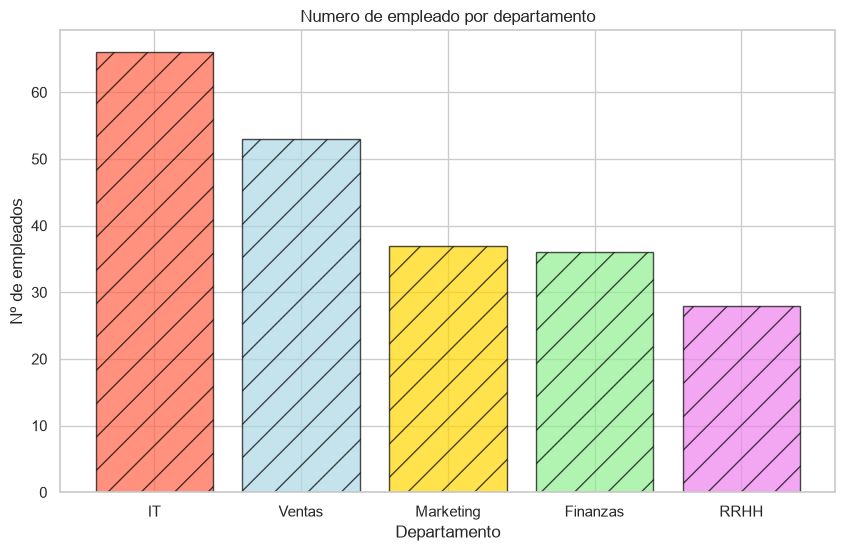

In [388]:
conteo_dpto = df['departamento'].value_counts().reset_index()
conteo_dpto.columns = ['departamento','cantidad']

# matplotlib
plt.figure(figsize=(10,6))
plt.title('Numero de empleado por departamento')
plt.bar(conteo_dpto['departamento'], conteo_dpto['cantidad'], alpha=0.7, edgecolor='black', color=['tomato', 'lightblue', 'gold', 'lightgreen', 'violet'], hatch="/")
plt.xlabel('Departamento')
plt.ylabel('Nº de empleados')
plt.show()


5.2 Distribución de la edad:

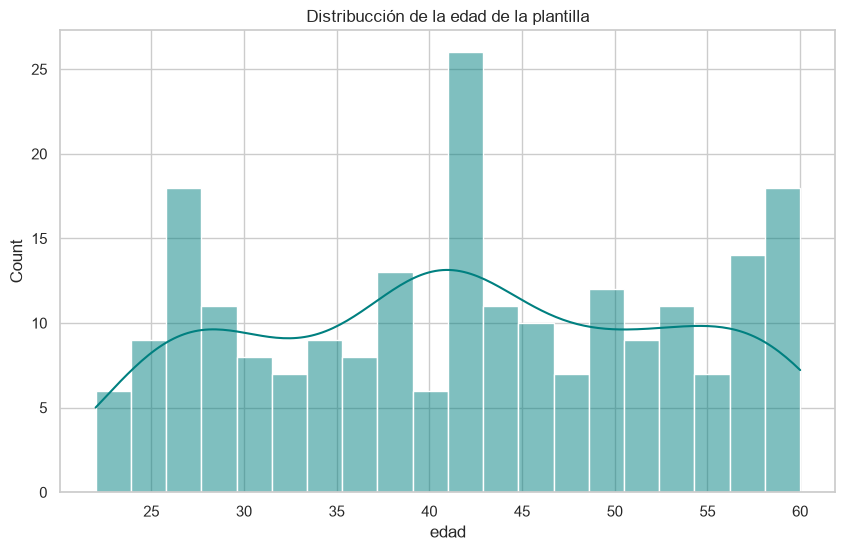

In [389]:
plt.figure(figsize=(10,6))
plt.title('Distribucción de la edad de la plantilla')
sns.histplot(data=df, x='edad', kde=True, color='teal', bins=20)
plt.show()

5.3 Distribución del salario

Vamos a usar boxplot por que nos permite ver la mediana, rango intercuartílico y valores atipicos.

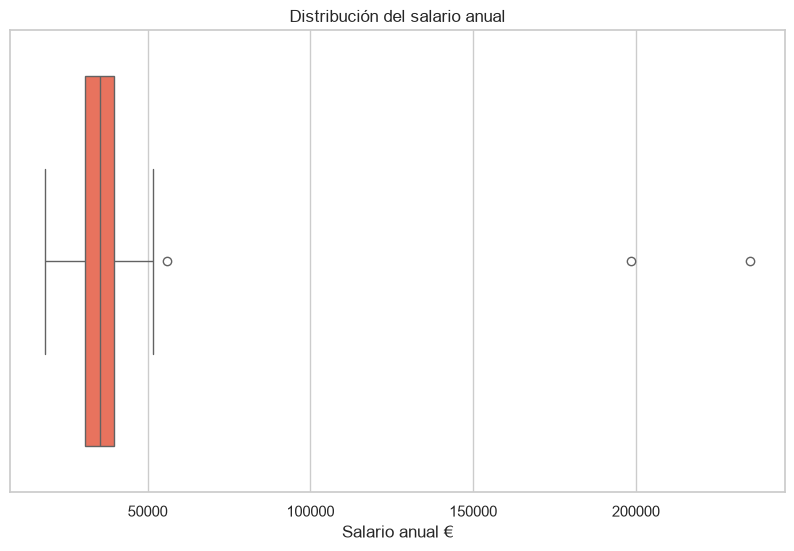

In [390]:
plt.figure(figsize=(10,6))
plt.title('Distribución del salario anual')
sns.boxplot(data=df, x="salario_anual", color='tomato')
plt.xlabel('Salario anual €')
plt.show()

In [391]:
# ¿Quienes son esos salarios outliers que se salen de rango?
df[ df['salario_anual'] > 100000 ][ ['nombre', 'departamento', 'antiguedad_anios', 'salario_anual'] ]

#Salario medio:
int(df['salario_anual'].mean())
# Salario redondea a dos decimales
df['salario_anual'].mean().round(2)


np.float64(36902.47)

5.4 Reparto por genero.

genero
Hombre    118
Mujer     102
Name: count, dtype: int64


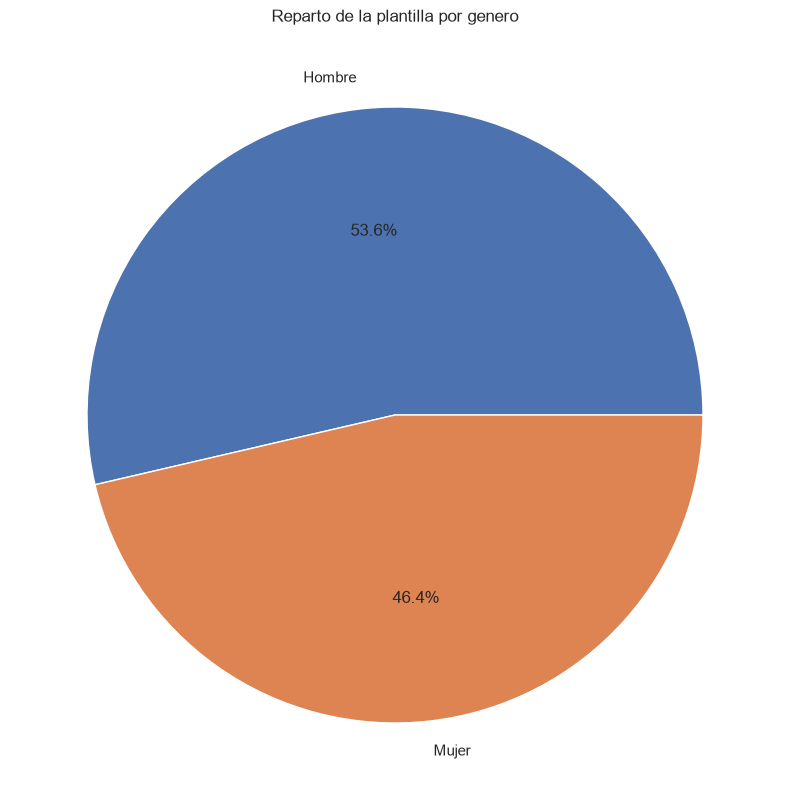

In [392]:
conteo_genero = df['genero'].value_counts()
print(conteo_genero)

plt.figure(figsize=(10, 10))
plt.title('Reparto de la plantilla por genero')
plt.pie(
    conteo_genero,
    labels=conteo_genero.index,
    autopct='%1.1f%%'
)
plt.show()

## 6. Análisis Bivariante

Vamos cruzar variables entre si para establecer relaciones.

6.1 Salario medio por departamento.

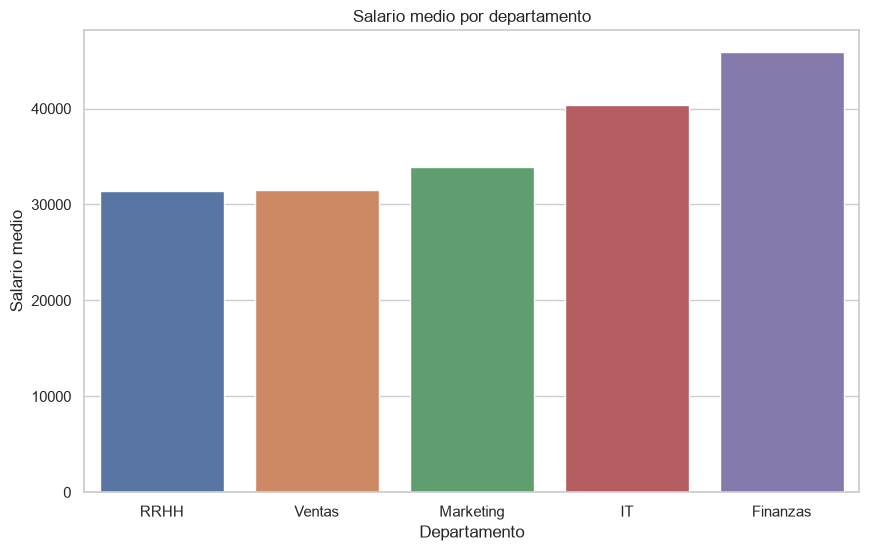

,departamento,salario_anual
3,RRHH,31449.90
4,Ventas,31478.43
2,Marketing,33945.89
1,IT,40338.71
0,Finanzas,45867.66


In [393]:
salario_medio_dpto = (
    df.groupby('departamento')['salario_anual']
    .mean()
    .round(2)
    .reset_index()
    .sort_values('salario_anual', ascending=True)
)

plt.figure(figsize=(10,6))
plt.title('Salario medio por departamento')
sns.barplot(data=salario_medio_dpto, x="departamento", y="salario_anual", hue="departamento", legend=False)
plt.xlabel('Departamento')
plt.ylabel('Salario medio')
plt.show()

salario_medio_dpto

6.2 Relación entre edad y salario

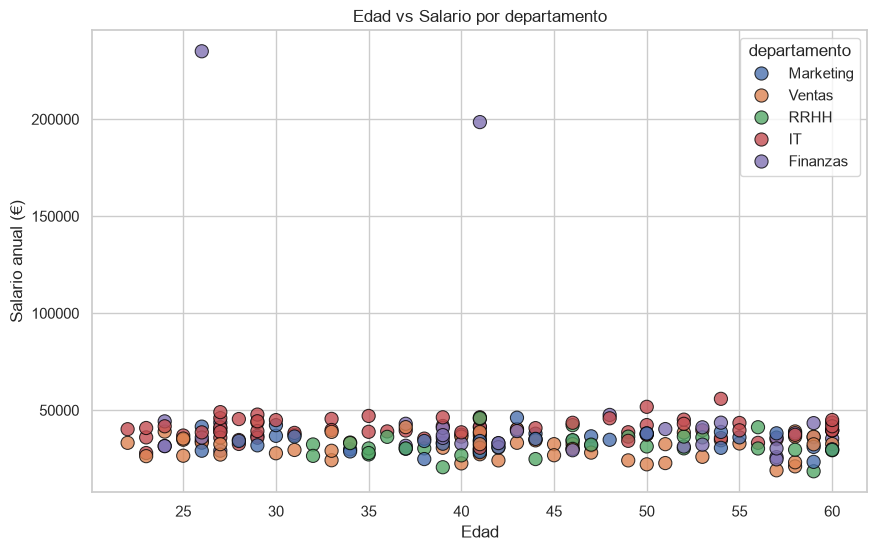

In [394]:
plt.figure(figsize=(10,6))
plt.title('Edad vs Salario por departamento')
sns.scatterplot(data=df, x="edad", y="salario_anual", hue="departamento", s=90, alpha=0.8, edgecolor="black")
plt.xlabel('Edad')
plt.ylabel('Salario anual (€)')
plt.show()

6.3 ¿Influye el teletrabajo en la satisfacción de los trabajadores?

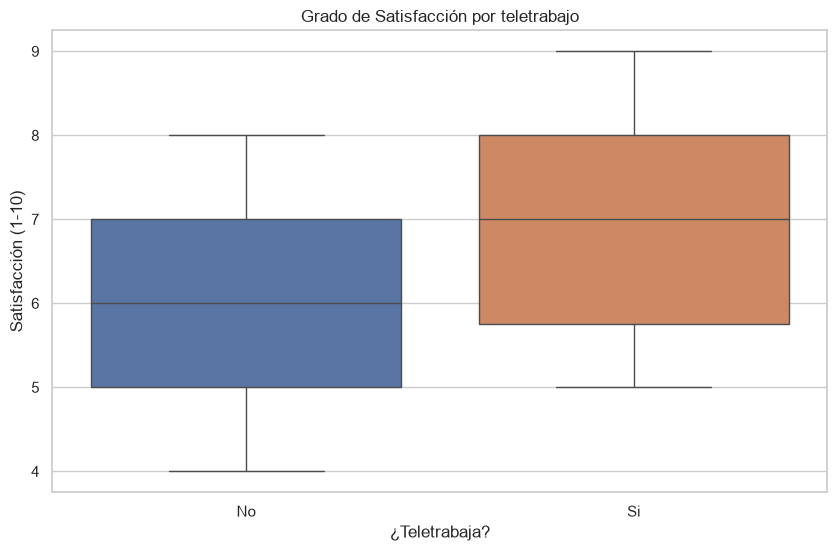

In [395]:
plt.figure(figsize=(10,6))
plt.title('Grado de Satisfacción por teletrabajo')
sns.boxplot(data=df, x="teletrabajo", y="satisfaccion", hue="teletrabajo", legend=False)
plt.xlabel('¿Teletrabaja?')
plt.ylabel('Satisfacción (1-10)')
plt.xticks([False,True],['No', 'Si'])
plt.show()

7. Correlación entre varibles numéricas.
La matriz de correlación nos dice , de un vistazo, que variables numéricas se mueven juntas

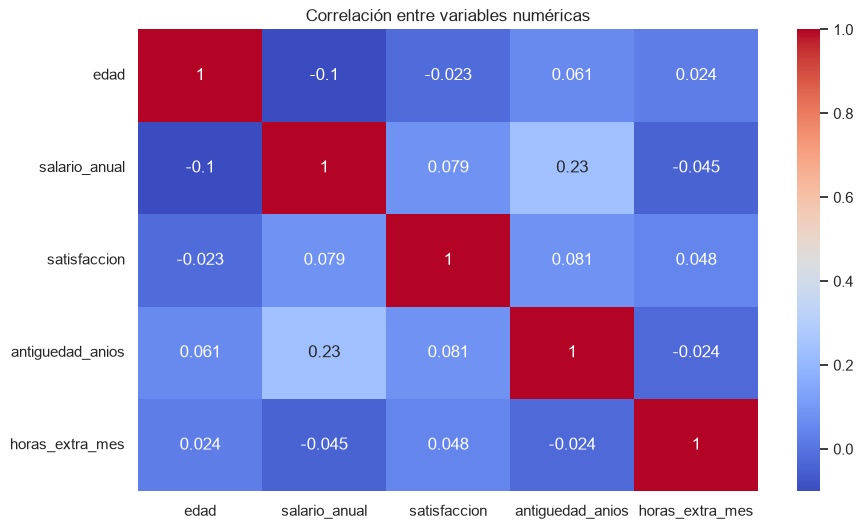

In [396]:
columnas_numericas = ['edad', 'salario_anual', 'satisfaccion', 'antiguedad_anios', 'horas_extra_mes']

matriz_correlacion = df[columnas_numericas].corr()

plt.figure(figsize=(10,6))
plt.title('Correlación entre variables numéricas')
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm')
plt.show()

### 8. Gráfico Interactivo con Plotly

Como ya sabeis con plotly podemos crear el mismo tipo de grafico pero **interactivos**:

In [397]:
fig = px.box(
    df,
    x="departamento",
    y="salario_anual",
    color='departamento',
    points="all",
    title="Distribución del salario por departamento",
    labels={'departamento': 'Departamento', 'salario_anual': 'Salario Anual (€)'}
)

fig.show()

---
## Resumen de funciones utilizadas

| Función / Sintaxis | ¿Para qué sirve? |
|---|---|
| `pd.read_csv()` | Cargar los datos |
| `df.shape` / `df.info()` / `df.describe()` | Primera exploración |
| `df.isnull().sum()` | Contar nulos por columna |
| `df.duplicated()` / `df.drop_duplicates()` | Detectar y eliminar duplicados |
| `df[col].value_counts()` | Distribución de una columna categórica |
| `.str.strip()` / `.str.upper()` / `.replace()` | Normalizar texto |
| `df[col].fillna(valor)` | Rellenar nulos |
| `df.groupby(col).transform()` | Rellenar nulos con un valor por grupo |
| `df.astype()` | Cambiar el tipo de una columna |
| `sns.barplot` / `sns.histplot` / `sns.boxplot` / `sns.scatterplot` / `sns.heatmap` | Visualización estática (seaborn) |
| `plt.pie` | Gráfico de sectores (matplotlib) |
| `df[cols].corr()` | Matriz de correlación |
| `px.box` | Gráfico interactivo (plotly) |
| `requests.get()` / `requests.post()` | Llamar a un webhook de n8n (traer datos / enviar el informe) |

## 9. Conclusiones

In [398]:
json_data = df.to_json(orient="records")

resumen = {
    "fecha_informe": pd.Timestamp.today().strftime('%d-%m-%Y %H:%M'),
    "total_empleados": len(df),
    "salario_medio": float(df['salario_anual'].mean().round(2)),
    "departamento_mas_grande": df['departamento'].value_counts().idxmax(),
    "numero_empleados_departamento_mas_grande":  int(df['departamento'].value_counts().max()),
    "empleados_hacen_teletrabajo": f"{int(df['teletrabajo'].mean() * 100)}%",
    "data": json_data
}


URL_INFORME = "https://juanan.n8ncamp.com/webhook-test/montar-informe"

response = rq.post(URL_INFORME, json=resumen)
conclusiones = response.json()
fichero = open('./data/conclusiones.txt', 'w', encoding='utf-8')
fichero.write(conclusiones['text'])
fichero.close()

